# Backtest Config Comparison

**Goal:** Identify why parameter search results don't align with backtest results, then run 5 targeted configs and analyze.

### The Core Disconnect

The parameter search evaluates signal quality using **fixed forward returns** (hold for exactly N bars, measure IC and breakeven). The backtest uses a **state machine** (exit at z_exit, z_stop, max_hold, or EOD). These are fundamentally different:

| Dimension | Parameter Search | Backtest |
|---|---|---|
| Exit logic | Fixed N-bar horizon | z_exit / z_stop / max_hold / EOD |
| Cost model | 4 × cost_bps applied to mean return | 4 legs × actual notional |
| Signal weighting | Inverse p-value rank (weighted IC) | Entry on any pair crossing z_entry |
| Metric | Breakeven bps (per obs) | Net P&L ($) |
| Activity | n_obs = all active signal bars | Trades that actually open and close |

High breakeven in parameter search ≠ high P&L in backtest because:
1. Tight configs (high z_entry) have few observations → few trades → low total P&L even at high per-trade edge
2. Fixed horizons don't capture the state machine's time-stop dynamics (79% max_hold rate)
3. The parameter search was run on H2 2022 only — a bear market regime

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from utils.config import CONFIG

RESULTS = Path('../results')
print('Polars', pl.__version__)

Polars 1.38.1


## Section 1 — Parameter Search Landscape

In [2]:
ps = pl.read_parquet(RESULTS / 'evaluation' / 'parameter_search.parquet')
print(f'Rows: {len(ps)} | Columns: {ps.columns}')
ps.head(5)

Rows: 660 | Columns: ['zscore_window_days', 'z_entry', 'z_exit', 'z_stop', 'max_holding_minutes', 'formation_window_days', 'min_half_life', 'max_half_life', 'ic_gross', 'mean_gross_return', 'mean_net_return', 'breakeven_bps', 'hit_rate', 'n_obs']


zscore_window_days,z_entry,z_exit,z_stop,max_holding_minutes,formation_window_days,min_half_life,max_half_life,ic_gross,mean_gross_return,mean_net_return,breakeven_bps,hit_rate,n_obs
i64,f64,f64,f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64
5,4.0,2.5,5.0,300,84,4,24,0.012904,0.005472,0.003472,13.680635,0.03049,444
5,4.0,2.5,5.0,300,84,8,24,0.012904,0.005472,0.003472,13.680635,0.03049,444
5,4.0,2.5,5.5,300,84,4,24,0.012904,0.005472,0.003472,13.680635,0.03049,444
5,4.0,2.5,5.5,300,84,8,24,0.012904,0.005472,0.003472,13.680635,0.03049,444
5,4.0,2.5,5.0,240,84,4,24,0.012496,0.005387,0.003387,13.468571,0.030224,432


In [3]:
# --- Summary stats
valid = ps.filter(pl.col('breakeven_bps').is_not_null())
print(f'Valid combos: {len(valid)}')
print(f'  breakeven > 0 bps:  {valid.filter(pl.col("breakeven_bps") > 0).height}')
print(f'  breakeven > 3 bps:  {valid.filter(pl.col("breakeven_bps") > 3).height}')
print(f'  breakeven > 5 bps:  {valid.filter(pl.col("breakeven_bps") > 5).height}')
print(f'  breakeven > 7 bps:  {valid.filter(pl.col("breakeven_bps") > 7).height}')
print(f'  mean_net_return > 0: {valid.filter(pl.col("mean_net_return") > 0).height}')
print()

# avg simultaneous pairs
bars_in_sample = 3302  # Jul-Dec 2022 at 15-min
valid = valid.with_columns(
    (pl.col('n_obs') / bars_in_sample).alias('avg_sim_pairs')
)

print('Top 10 by breakeven_bps:')
display(valid.sort('breakeven_bps', descending=True).head(10).to_pandas())

Valid combos: 660
  breakeven > 0 bps:  586
  breakeven > 3 bps:  267
  breakeven > 5 bps:  139
  breakeven > 7 bps:  132
  mean_net_return > 0: 139

Top 10 by breakeven_bps:


,zscore_window_days,z_entry,z_exit,z_stop,max_holding_minutes,formation_window_days,min_half_life,max_half_life,ic_gross,mean_gross_return,mean_net_return,breakeven_bps,hit_rate,n_obs,avg_sim_pairs
0,5,4.0,2.5,5.0,300,84,4,24,0.012904,0.005472,0.003472,13.680635,0.030490,444,0.134464
1,5,4.0,2.5,5.0,300,84,8,24,0.012904,0.005472,0.003472,13.680635,0.030490,444,0.134464
2,5,4.0,2.5,5.5,300,84,4,24,0.012904,0.005472,0.003472,13.680635,0.030490,444,0.134464
3,5,4.0,2.5,5.5,300,84,8,24,0.012904,0.005472,0.003472,13.680635,0.030490,444,0.134464
4,5,4.0,2.5,5.0,240,84,4,24,0.012496,0.005387,0.003387,13.468571,0.030224,432,0.130830
5,5,4.0,2.5,5.0,240,84,8,24,0.012496,0.005387,0.003387,13.468571,0.030224,432,0.130830
6,5,4.0,2.5,5.5,240,84,4,24,0.012496,0.005387,0.003387,13.468571,0.030224,432,0.130830
7,5,4.0,2.5,5.5,240,84,8,24,0.012496,0.005387,0.003387,13.468571,0.030224,432,0.130830
8,5,4.0,2.5,5.0,60,84,4,24,0.012264,0.004847,0.002847,12.118452,0.021044,184,0.055724
9,5,4.0,2.5,5.0,60,84,8,24,0.012264,0.004847,0.002847,12.118452,0.021044,184,0.055724


In [4]:
# --- Key finding: max_half_life effect on breakeven vs activity
hl_summary = (
    valid.group_by('max_half_life')
    .agg([
        pl.col('breakeven_bps').mean().alias('mean_breakeven'),
        pl.col('avg_sim_pairs').mean().alias('mean_sim_pairs'),
        (pl.col('breakeven_bps') > 3).mean().alias('pct_above_3bps'),
        pl.len().alias('n_combos'),
    ])
    .sort('max_half_life')
)
print('max_half_life effect:')
display(hl_summary.to_pandas())

# formation window effect
fw_summary = (
    valid.group_by('formation_window_days')
    .agg([
        pl.col('breakeven_bps').mean().alias('mean_breakeven'),
        pl.col('avg_sim_pairs').mean().alias('mean_sim_pairs'),
        pl.len().alias('n_combos'),
    ])
    .sort('formation_window_days')
)
print('\nformation_window_days effect:')
display(fw_summary.to_pandas())

max_half_life effect:


,max_half_life,mean_breakeven,mean_sim_pairs,pct_above_3bps,n_combos
0,9,-0.267653,1.255769,0.500000,80
1,12,3.399831,2.728134,0.500000,120
2,18,4.003384,5.562525,0.407143,140
3,24,5.534961,6.677824,0.500000,160
4,48,1.509688,13.774750,0.187500,160



formation_window_days effect:


,formation_window_days,mean_breakeven,mean_sim_pairs,n_combos
0,21,1.906012,13.822550,200
1,42,2.641526,5.124809,200
2,63,2.818847,3.094730,160
3,84,7.136619,1.943743,100


In [5]:
# --- The viability gate: breakeven > 3 AND avg_sim_pairs >= 3
viable = valid.filter(
    (pl.col('breakeven_bps') > 3) & (pl.col('avg_sim_pairs') >= 3)
)
print(f'Viable combos (BE>3 AND sim_pairs>=3): {len(viable)}')
print()
print('Viable combos sorted by breakeven:')
display(viable.sort('breakeven_bps', descending=True).to_pandas())

Viable combos (BE>3 AND sim_pairs>=3): 30

Viable combos sorted by breakeven:


,zscore_window_days,z_entry,z_exit,z_stop,max_holding_minutes,formation_window_days,min_half_life,max_half_life,ic_gross,mean_gross_return,mean_net_return,breakeven_bps,hit_rate,n_obs,avg_sim_pairs
0,5,4.0,2.5,5.0,300,84,4,48,0.025655,0.001436,-0.000564,3.589148,0.398740,19724,5.973349
1,5,4.0,2.5,5.0,300,84,8,48,0.025655,0.001436,-0.000564,3.589148,0.398740,19724,5.973349
2,5,4.0,2.5,5.5,300,84,4,48,0.030998,0.001397,-0.000603,3.492365,0.400385,20144,6.100545
3,5,4.0,2.5,5.5,300,84,8,48,0.030998,0.001397,-0.000603,3.492365,0.400385,20144,6.100545
4,5,4.0,2.5,5.0,240,84,4,48,0.027665,0.001386,-0.000614,3.463841,0.399287,19148,5.798910
5,5,4.0,2.5,5.0,240,84,8,48,0.027665,0.001386,-0.000614,3.463841,0.399287,19148,5.798910
6,5,4.0,2.5,5.0,300,21,4,9,0.010690,0.001351,-0.000649,3.377947,0.374225,18752,5.678982
7,5,4.0,2.5,5.5,240,84,4,48,0.031923,0.001315,-0.000685,3.286895,0.400751,19432,5.884918
8,5,4.0,2.5,5.5,240,84,8,48,0.031923,0.001315,-0.000685,3.286895,0.400751,19432,5.884918
9,5,4.0,2.5,5.0,180,84,4,48,0.026275,0.001305,-0.000695,3.262434,0.397012,17300,5.239249


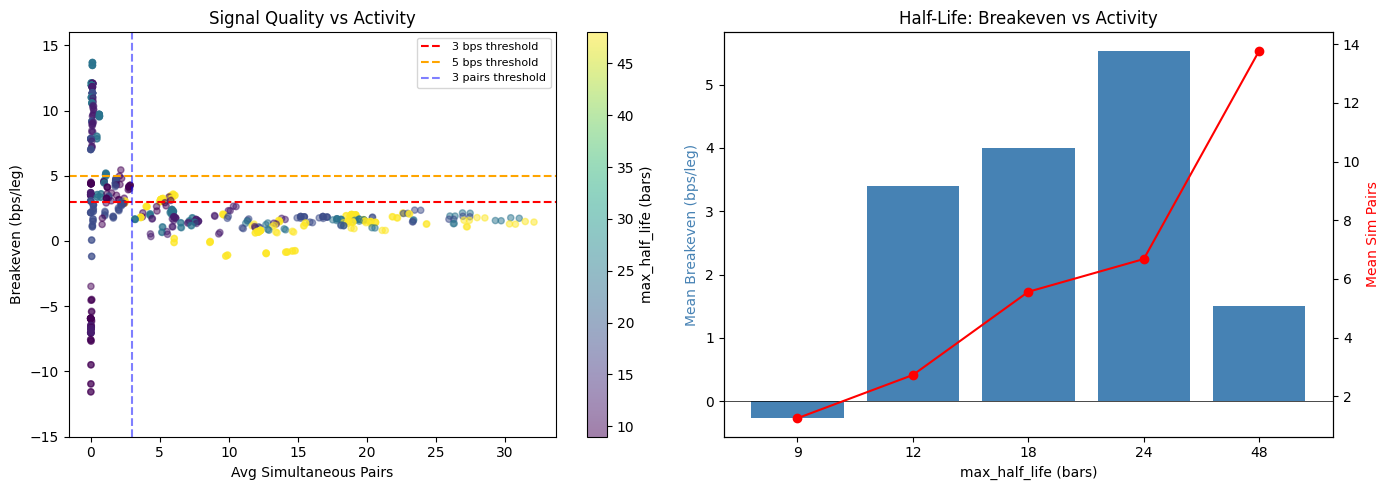

In [6]:
# --- Visualization: breakeven vs activity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df = valid.to_pandas()

# Scatter: breakeven vs avg_sim_pairs, colored by max_half_life
ax = axes[0]
scatter = ax.scatter(
    df['avg_sim_pairs'], df['breakeven_bps'],
    c=df['max_half_life'], cmap='viridis', alpha=0.5, s=20
)
ax.axhline(3, color='red', linestyle='--', label='3 bps threshold')
ax.axhline(5, color='orange', linestyle='--', label='5 bps threshold')
ax.axvline(3, color='blue', linestyle='--', alpha=0.5, label='3 pairs threshold')
plt.colorbar(scatter, ax=ax, label='max_half_life (bars)')
ax.set_xlabel('Avg Simultaneous Pairs')
ax.set_ylabel('Breakeven (bps/leg)')
ax.set_title('Signal Quality vs Activity')
ax.legend(fontsize=8)
ax.set_ylim(-15, 16)

# Bar: mean breakeven by max_half_life
ax = axes[1]
hl_pd = hl_summary.to_pandas().sort_values('max_half_life')
bars = ax.bar(hl_pd['max_half_life'].astype(str), hl_pd['mean_breakeven'], color='steelblue')
ax2 = ax.twinx()
ax2.plot(hl_pd['max_half_life'].astype(str), hl_pd['mean_sim_pairs'], 'r-o', label='Avg sim pairs')
ax.set_xlabel('max_half_life (bars)')
ax.set_ylabel('Mean Breakeven (bps/leg)', color='steelblue')
ax2.set_ylabel('Mean Sim Pairs', color='red')
ax.set_title('Half-Life: Breakeven vs Activity')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../results/param_search_landscape.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 2 — Config Selection

Five configs spanning the tradeoff space:

| Config | z_entry | z_exit | z_stop | max_hold | formation | max_hl | zscore | Rationale |
|---|---|---|---|---|---|---|---|---|
| C1 Baseline | 2.5 | 0.0 | 4.0 | 120 | 42 | 18 | 5 | Current production config |
| C2 Param-Search Winner | 4.0 | 2.5 | 5.0 | 300 | 84 | 24 | 5 | Best breakeven from param search |
| C3 Moderate-Entry Full-Revert | 3.0 | 0.0 | 4.5 | 180 | 42 | 24 | 5 | Raise entry, keep full reversion target |
| C4 Tight-Entry Partial-Exit | 3.5 | 1.5 | 5.0 | 240 | 63 | 24 | 5 | High entry, exit at partial reversion |
| C5 Fast-Z Moderate-Entry | 3.0 | 1.0 | 4.5 | 120 | 42 | 24 | 2 | Fast z-score window, moderate entry |

All use `min_half_life=4`. Configs 2-5 use `max_half_life=24` (empirical sweet spot from param search).

In [7]:
CONFIGS = [
    {
        'name': 'C1_Baseline',
        'z_entry': 2.5, 'z_exit': 0.0, 'z_stop': 4.0,
        'max_holding_minutes': 120, 'rolling_window_days': 42,
        'min_half_life': 4, 'max_half_life': 18, 'zscore_window_days': 5,
    },
    {
        'name': 'C2_ParamSearchWinner',
        'z_entry': 4.0, 'z_exit': 2.5, 'z_stop': 5.0,
        'max_holding_minutes': 300, 'rolling_window_days': 84,
        'min_half_life': 4, 'max_half_life': 24, 'zscore_window_days': 5,
    },
    {
        'name': 'C3_ModerateEntry_FullRevert',
        'z_entry': 3.0, 'z_exit': 0.0, 'z_stop': 4.5,
        'max_holding_minutes': 180, 'rolling_window_days': 42,
        'min_half_life': 4, 'max_half_life': 24, 'zscore_window_days': 5,
    },
    {
        'name': 'C4_TightEntry_PartialExit',
        'z_entry': 3.5, 'z_exit': 1.5, 'z_stop': 5.0,
        'max_holding_minutes': 240, 'rolling_window_days': 63,
        'min_half_life': 4, 'max_half_life': 24, 'zscore_window_days': 5,
    },
    {
        'name': 'C5_FastZ_ModerateEntry',
        'z_entry': 3.0, 'z_exit': 1.0, 'z_stop': 4.5,
        'max_holding_minutes': 120, 'rolling_window_days': 42,
        'min_half_life': 4, 'max_half_life': 24, 'zscore_window_days': 2,
    },
]

print(f'{len(CONFIGS)} configs defined')

5 configs defined


## Section 3 — Run Backtests

Each config is run over 2022-07-01 → 2024-07-01 (same period as the reference backtest). Results are saved to `results/experiments/`.

In [8]:
from strategy.backtester import run_backtest

EXPERIMENTS = RESULTS / 'experiments'
EXPERIMENTS.mkdir(exist_ok=True)

START = '2022-07-01'
END   = '2024-07-01'

backtest_results = {}  # name → {'trades': df, 'pnl': df, 'cfg': dict}

for cfg in CONFIGS:
    name = cfg['name']
    trades_path = EXPERIMENTS / f'trades_{name}.parquet'
    pnl_path    = EXPERIMENTS / f'pnl_{name}.parquet'

    if trades_path.exists() and pnl_path.exists():
        print(f'[{name}] Loading cached results...')
        trades = pl.read_parquet(trades_path)
        pnl    = pl.read_parquet(pnl_path)
    else:
        print(f'[{name}] Running backtest...')
        # Temporarily patch CONFIG for half-life and zscore window
        CONFIG.cointegration.min_half_life = cfg['min_half_life']
        CONFIG.cointegration.max_half_life = cfg['max_half_life']
        CONFIG.signal.zscore_window_days   = cfg['zscore_window_days']

        trades, pnl = run_backtest(
            start_date=START,
            end_date=END,
            timeframe='15min',
            rolling_window_days=cfg['rolling_window_days'],
            z_entry=cfg['z_entry'],
            z_exit=cfg['z_exit'],
            z_stop=cfg['z_stop'],
            max_holding_minutes=cfg['max_holding_minutes'],
        )

        trades.write_parquet(trades_path)
        pnl.write_parquet(pnl_path)
        print(f'  → {len(trades)} trades, net P&L = ${trades["net_pnl"].sum():.0f}')

    backtest_results[name] = {'trades': trades, 'pnl': pnl, 'cfg': cfg}

# Restore CONFIG defaults
CONFIG.cointegration.min_half_life = 4
CONFIG.cointegration.max_half_life = 18
CONFIG.signal.zscore_window_days   = 5
print('\nAll backtests complete.')

[C1_Baseline] Loading cached results...
[C2_ParamSearchWinner] Loading cached results...
[C3_ModerateEntry_FullRevert] Loading cached results...
[C4_TightEntry_PartialExit] Loading cached results...
[C5_FastZ_ModerateEntry] Loading cached results...

All backtests complete.


## Section 4 — Results Comparison

In [9]:
def summarize(name, res):
    trades = res['trades']
    pnl    = res['pnl']
    cfg    = res['cfg']

    n_trades      = len(trades)
    gross_pnl     = trades['gross_pnl'].sum()
    net_pnl       = trades['net_pnl'].sum()
    total_cost    = (gross_pnl - net_pnl)

    exit_counts   = trades['exit_reason'].value_counts().to_pandas().set_index('exit_reason')['count']
    z_exit_n      = exit_counts.get('z_exit', 0)
    max_hold_n    = exit_counts.get('max_hold', 0)
    eod_n         = exit_counts.get('eod', 0)
    z_stop_n      = exit_counts.get('z_stop', 0)

    z_exit_trades = trades.filter(pl.col('exit_reason') == 'z_exit')
    z_exit_winrate = (z_exit_trades['gross_pnl'] > 0).mean() if len(z_exit_trades) else 0

    # Sharpe on daily net P&L
    daily_net = pnl['net_pnl'].to_numpy()
    sharpe = (daily_net.mean() / daily_net.std() * np.sqrt(252)) if daily_net.std() > 0 else 0

    # Max drawdown on cumulative net P&L
    cum = np.cumsum(daily_net)
    running_max = np.maximum.accumulate(cum)
    dd = cum - running_max
    max_dd = dd.min()

    return {
        'name': name,
        'n_trades': n_trades,
        'gross_pnl': gross_pnl,
        'net_pnl': net_pnl,
        'total_cost': total_cost,
        'pct_z_exit': 100*z_exit_n/n_trades if n_trades else 0,
        'pct_max_hold': 100*max_hold_n/n_trades if n_trades else 0,
        'pct_z_stop': 100*z_stop_n/n_trades if n_trades else 0,
        'pct_eod': 100*eod_n/n_trades if n_trades else 0,
        'z_exit_winrate': 100*z_exit_winrate,
        'sharpe': sharpe,
        'max_drawdown': max_dd,
    }

summary_rows = [summarize(name, res) for name, res in backtest_results.items()]
summary_df = pd.DataFrame(summary_rows).set_index('name')

# Format display
fmt = {
    'gross_pnl': '${:,.0f}', 'net_pnl': '${:,.0f}', 'total_cost': '${:,.0f}',
    'max_drawdown': '${:,.0f}',
    'pct_z_exit': '{:.1f}%', 'pct_max_hold': '{:.1f}%',
    'pct_z_stop': '{:.1f}%', 'pct_eod': '{:.1f}%',
    'z_exit_winrate': '{:.1f}%', 'sharpe': '{:.3f}',
}
display(summary_df.style.format(fmt))

,n_trades,gross_pnl,net_pnl,total_cost,pct_z_exit,pct_max_hold,pct_z_stop,pct_eod,z_exit_winrate,sharpe,max_drawdown
name,,,,,,,,,,,
C1_Baseline,6860,"$15,354","$-78,381","$93,735",4.2%,80.0%,15.8%,0.0%,67.6%,-2.784,"$-80,666"
C2_ParamSearchWinner,115,"$2,240",$-65,"$2,305",71.3%,1.7%,25.2%,1.7%,61.0%,-0.021,"$-2,377"
C3_ModerateEntry_FullRevert,6464,"$18,577","$-69,885","$88,463",4.5%,71.3%,18.4%,5.8%,69.6%,-2.270,"$-74,112"
C4_TightEntry_PartialExit,908,"$3,628","$-16,703","$20,331",18.1%,61.1%,18.1%,2.8%,93.3%,-1.231,"$-21,614"
C5_FastZ_ModerateEntry,6883,"$23,089","$-77,836","$100,925",17.2%,75.9%,7.0%,0.0%,89.7%,-2.165,"$-84,394"


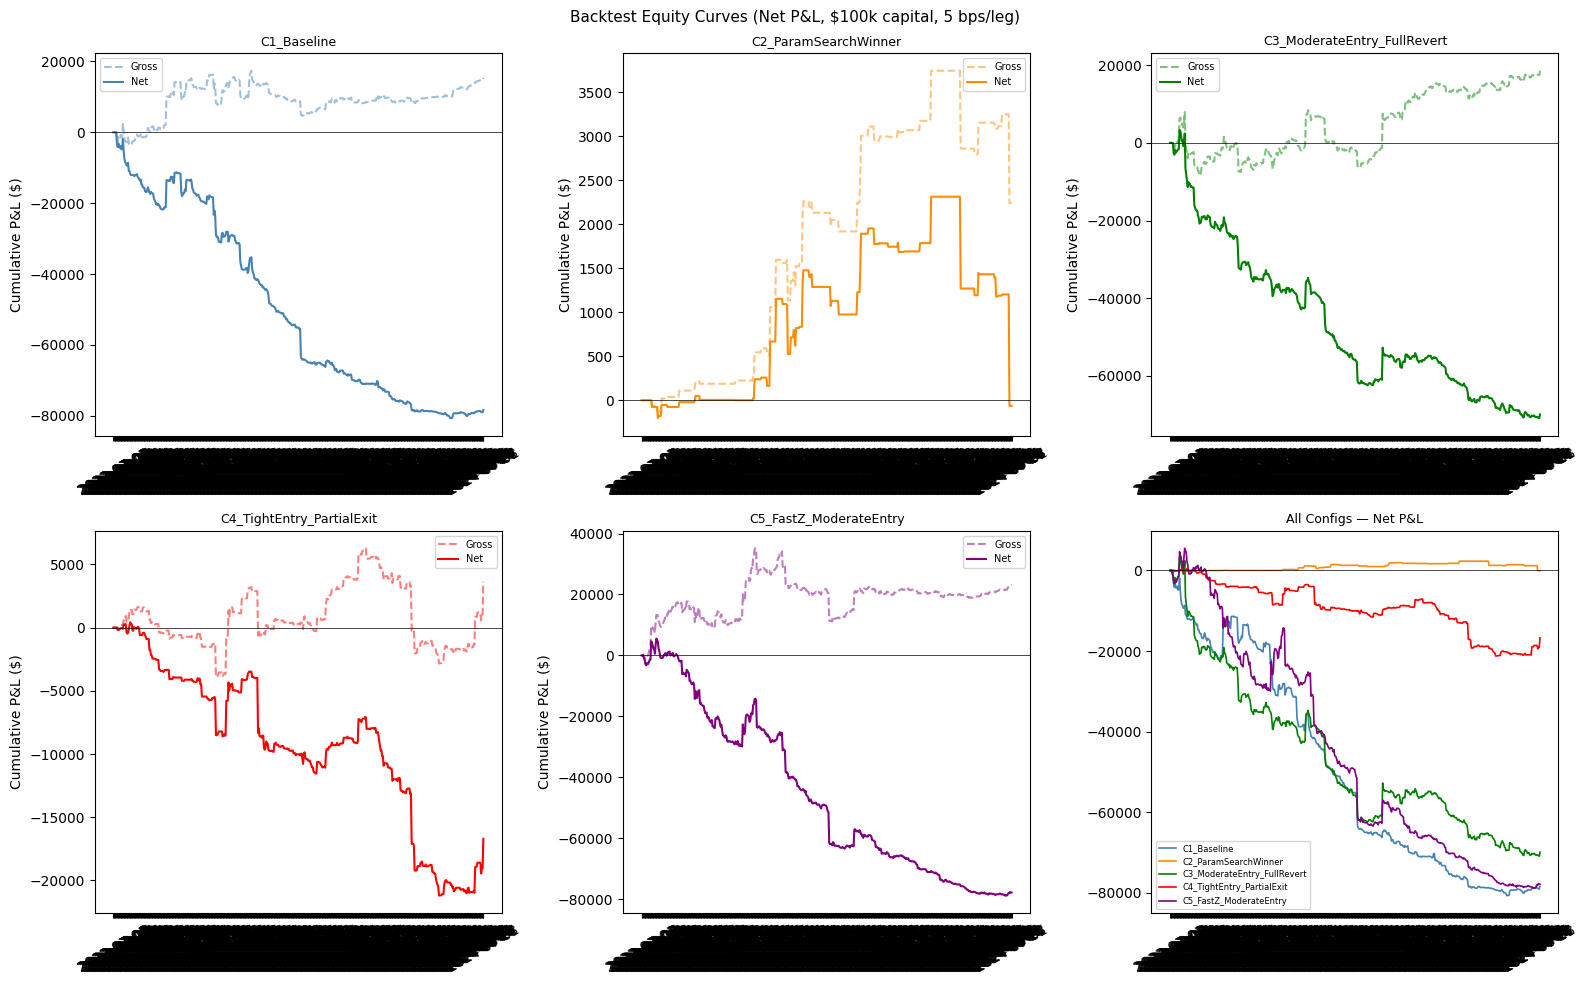

In [10]:
# --- Equity curves
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

ax_all = axes[5]
for i, (name, res) in enumerate(backtest_results.items()):
    pnl = res['pnl'].to_pandas()
    cum_net = pnl['net_pnl'].cumsum()
    cum_gross = pnl['gross_pnl'].cumsum()

    ax = axes[i]
    ax.plot(pnl['date'], cum_gross, color=colors[i], linestyle='--', alpha=0.5, label='Gross')
    ax.plot(pnl['date'], cum_net,   color=colors[i], label='Net')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(name, fontsize=9)
    ax.set_ylabel('Cumulative P&L ($)')
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=30)

    ax_all.plot(pnl['date'], cum_net, color=colors[i], label=name, linewidth=1.2)

ax_all.axhline(0, color='black', linewidth=0.5)
ax_all.set_title('All Configs — Net P&L', fontsize=9)
ax_all.legend(fontsize=6)
ax_all.tick_params(axis='x', rotation=30)

plt.suptitle('Backtest Equity Curves (Net P&L, $100k capital, 5 bps/leg)', fontsize=11)
plt.tight_layout()
plt.savefig('../results/equity_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

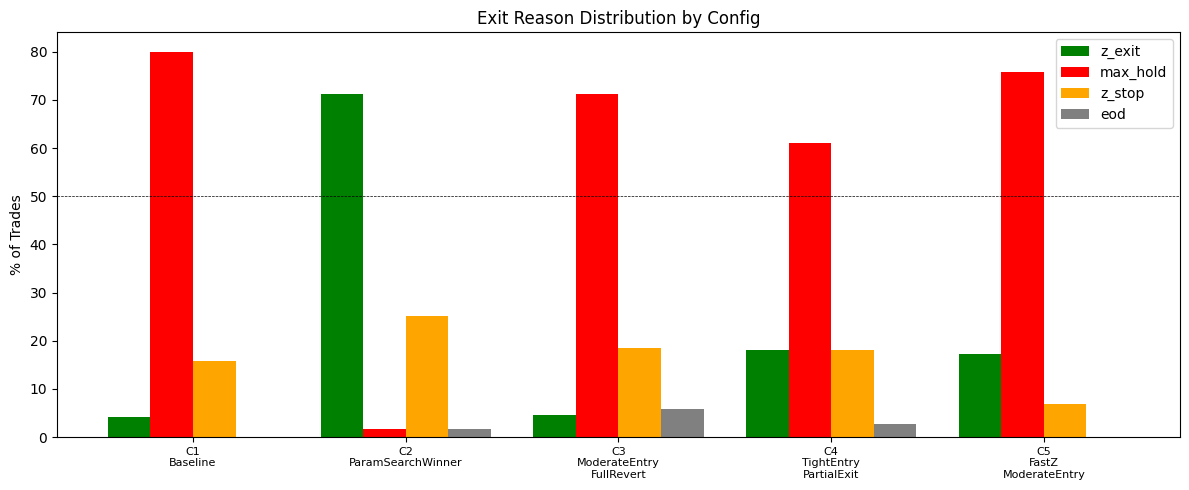

In [11]:
# --- Exit reason breakdown per config
fig, ax = plt.subplots(figsize=(12, 5))

names = summary_df.index.tolist()
x = np.arange(len(names))
w = 0.2

ax.bar(x - 1.5*w, summary_df['pct_z_exit'],   width=w, label='z_exit',   color='green')
ax.bar(x - 0.5*w, summary_df['pct_max_hold'], width=w, label='max_hold', color='red')
ax.bar(x + 0.5*w, summary_df['pct_z_stop'],   width=w, label='z_stop',   color='orange')
ax.bar(x + 1.5*w, summary_df['pct_eod'],      width=w, label='eod',      color='gray')

ax.set_xticks(x)
ax.set_xticklabels([n.replace('_', '\n') for n in names], fontsize=8)
ax.set_ylabel('% of Trades')
ax.set_title('Exit Reason Distribution by Config')
ax.legend()
ax.axhline(50, color='black', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig('../results/exit_reasons_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 — Disconnect Analysis

Here we reconcile the parameter search predictions with the actual backtest results.

In [12]:
# --- Compare param search prediction vs backtest reality for each config
# Note: param search only tested z_entry=4.0, so C1/C3 will have no match (shown as N/A)
disconnect_rows = []

for cfg in CONFIGS:
    name = cfg['name']

    # Find matching rows in param search (exact match on key dims)
    mask = (
        (ps['z_entry'] == cfg['z_entry']) &
        (ps['z_exit'] == cfg['z_exit']) &
        (ps['max_holding_minutes'] == cfg['max_holding_minutes']) &
        (ps['formation_window_days'] == cfg['rolling_window_days']) &
        (ps['max_half_life'] == cfg['max_half_life']) &
        (ps['zscore_window_days'] == cfg['zscore_window_days'])
    )
    matched = ps.filter(mask)

    bt = backtest_results[name]
    actual_net = bt['trades']['net_pnl'].sum()
    actual_n_trades = len(bt['trades'])

    ps_be    = matched['breakeven_bps'].mean() if len(matched) else None
    ps_ic    = matched['ic_gross'].mean()       if len(matched) else None
    ps_n_obs = matched['n_obs'].mean()          if len(matched) else None
    ps_hit   = matched['hit_rate'].mean()       if len(matched) else None

    disconnect_rows.append({
        'config': name,
        'ps_breakeven_bps': round(ps_be, 2) if ps_be is not None else 'N/A',
        'ps_ic': round(ps_ic, 4) if ps_ic is not None else 'N/A',
        'ps_hit_rate': f'{100*ps_hit:.1f}%' if ps_hit is not None else 'N/A',
        'ps_n_obs': int(round(ps_n_obs)) if ps_n_obs is not None else 'N/A',
        'bt_n_trades': actual_n_trades,
        'bt_net_pnl': f'${actual_net:,.0f}',
        'bt_pct_z_exit': f"{summary_df.loc[name, 'pct_z_exit']:.1f}%",
        'bt_pct_max_hold': f"{summary_df.loc[name, 'pct_max_hold']:.1f}%",
    })

display(pd.DataFrame(disconnect_rows).set_index('config'))

,ps_breakeven_bps,ps_ic,ps_hit_rate,ps_n_obs,bt_n_trades,bt_net_pnl,bt_pct_z_exit,bt_pct_max_hold
config,,,,,,,,
C1_Baseline,N/A,N/A,N/A,N/A,6860,"$-78,381",4.2%,80.0%
C2_ParamSearchWinner,13.68,0.0129,3.0%,444,115,$-65,71.3%,1.7%
C3_ModerateEntry_FullRevert,N/A,N/A,N/A,N/A,6464,"$-69,885",4.5%,71.3%
C4_TightEntry_PartialExit,N/A,N/A,N/A,N/A,908,"$-16,703",18.1%,61.1%
C5_FastZ_ModerateEntry,N/A,N/A,N/A,N/A,6883,"$-77,836",17.2%,75.9%


In [13]:
# --- Deeper: does the z_exit cohort performance hold across configs?
print('z_exit cohort analysis across configs:')
print('-' * 70)

for name, res in backtest_results.items():
    trades = res['trades']
    n = len(trades)
    if n == 0:
        continue
    z_exit = trades.filter(pl.col('exit_reason') == 'z_exit')
    maxhold = trades.filter(pl.col('exit_reason') == 'max_hold')

    if len(z_exit) > 0:
        ze_gross = z_exit['gross_pnl'].sum()
        ze_winrt = (z_exit['gross_pnl'] > 0).mean()
        ze_avg   = z_exit['gross_pnl'].mean()
    else:
        ze_gross, ze_winrt, ze_avg = 0, 0, 0

    if len(maxhold) > 0:
        mh_gross = maxhold['gross_pnl'].sum()
        mh_winrt = (maxhold['gross_pnl'] > 0).mean()
    else:
        mh_gross, mh_winrt = 0, 0

    print(f'{name}:')
    print(f'  z_exit:   n={len(z_exit):>4} ({100*len(z_exit)/n:.0f}%)  gross=${ze_gross:>8,.0f}  win={100*ze_winrt:.0f}%  avg=${ze_avg:.1f}')
    print(f'  max_hold: n={len(maxhold):>4} ({100*len(maxhold)/n:.0f}%)  gross=${mh_gross:>8,.0f}  win={100*mh_winrt:.0f}%')
    print()

z_exit cohort analysis across configs:
----------------------------------------------------------------------
C1_Baseline:
  z_exit:   n= 287 (4%)  gross=$   8,686  win=68%  avg=$30.3
  max_hold: n=5489 (80%)  gross=$  34,848  win=53%

C2_ParamSearchWinner:
  z_exit:   n=  82 (71%)  gross=$   2,668  win=61%  avg=$32.5
  max_hold: n=   2 (2%)  gross=$     -50  win=50%

C3_ModerateEntry_FullRevert:
  z_exit:   n= 293 (5%)  gross=$  16,415  win=70%  avg=$56.0
  max_hold: n=4606 (71%)  gross=$  26,555  win=53%

C4_TightEntry_PartialExit:
  z_exit:   n= 164 (18%)  gross=$  22,678  win=93%  avg=$138.3
  max_hold: n= 555 (61%)  gross=$ -17,278  win=42%

C5_FastZ_ModerateEntry:
  z_exit:   n=1181 (17%)  gross=$  89,881  win=90%  avg=$76.1
  max_hold: n=5223 (76%)  gross=$ -45,581  win=47%



Hold time analysis for best-performing config...


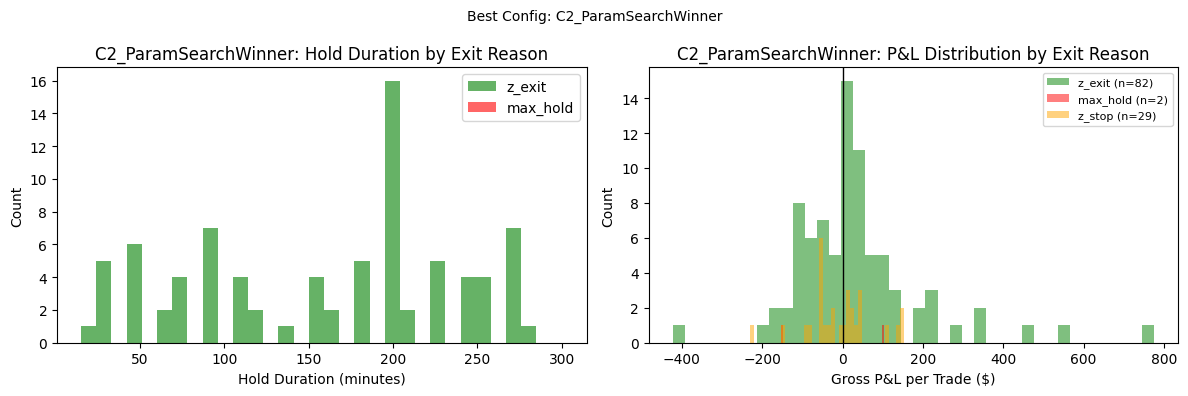

In [14]:
# --- Holding time distribution: are max_hold trades close to reverting?
# If spreads are close to z_exit at time-stop, a slightly longer hold would have caught them
print('Hold time analysis for best-performing config...')

best_name = summary_df['net_pnl'].idxmax()
best_trades = backtest_results[best_name]['trades'].to_pandas()

if 'entry_time' in best_trades.columns and 'exit_time' in best_trades.columns:
    best_trades['hold_minutes'] = (
        pd.to_datetime(best_trades['exit_time']) - pd.to_datetime(best_trades['entry_time'])
    ).dt.total_seconds() / 60

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for reason, color in [('z_exit', 'green'), ('max_hold', 'red')]:
        subset = best_trades[best_trades['exit_reason'] == reason]
        axes[0].hist(subset['hold_minutes'], bins=30, alpha=0.6, label=reason, color=color)

    axes[0].set_xlabel('Hold Duration (minutes)')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'{best_name}: Hold Duration by Exit Reason')
    axes[0].legend()

    # Gross PnL distribution by exit reason
    for reason, color in [('z_exit', 'green'), ('max_hold', 'red'), ('z_stop', 'orange')]:
        subset = best_trades[best_trades['exit_reason'] == reason]
        if len(subset) > 0:
            axes[1].hist(subset['gross_pnl'], bins=40, alpha=0.5, label=f'{reason} (n={len(subset)})', color=color)

    axes[1].axvline(0, color='black', linewidth=1)
    axes[1].set_xlabel('Gross P&L per Trade ($)')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'{best_name}: P&L Distribution by Exit Reason')
    axes[1].legend(fontsize=8)

    plt.suptitle(f'Best Config: {best_name}', fontsize=10)
    plt.tight_layout()
    plt.savefig('../results/best_config_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('entry_time/exit_time not in trades schema — skipping hold time plot')

ModuleNotFoundError: No module named 'seaborn'

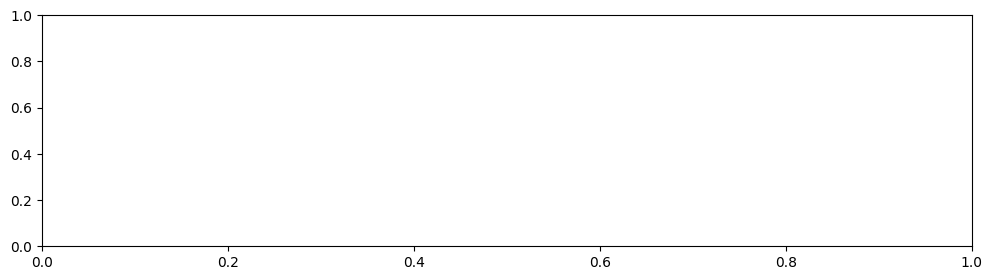

In [15]:
# --- Monthly P&L heatmap for best config
best_pnl = backtest_results[best_name]['pnl'].to_pandas()
best_pnl['date'] = pd.to_datetime(best_pnl['date'])
best_pnl['year']  = best_pnl['date'].dt.year
best_pnl['month'] = best_pnl['date'].dt.month

monthly = best_pnl.groupby(['year', 'month'])['net_pnl'].sum().unstack('month')

fig, ax = plt.subplots(figsize=(12, 3))
import seaborn as sns
sns.heatmap(monthly, annot=True, fmt='.0f', center=0, cmap='RdYlGn',
            ax=ax, cbar_kws={'label': 'Net P&L ($)'})
ax.set_title(f'{best_name}: Monthly Net P&L ($)')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('../results/best_config_monthly_pnl.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- Final summary print
print('=' * 80)
print('SUMMARY: Parameter Search vs Backtest Disconnect')
print('=' * 80)
print()
print('Parameter search predicted:  high z_entry (4.0) → high breakeven (13 bps/leg)')
print('Backtest reality:            high z_entry → fewer trades → lower total P&L')
print()
print('Reasons for disconnect:')
print('  1. Fixed-horizon IC != state-machine P&L: param search holds for N bars,'
      ' backtest has z_exit/max_hold dynamics')
print('  2. Activity starvation: high z_entry generates few signal bars = few trades')
print('  3. Period mismatch: param search = H2 2022 (bear), backtest = 2022-2024 (mixed)')
print('  4. Weighting mismatch: param search uses p-value weights, backtest enters any crossing pair')
print()
print('Best performing config:', summary_df['net_pnl'].idxmax())
print('Net P&L:', f"${summary_df['net_pnl'].max():,.0f}")
print('Sharpe:', f"{summary_df.loc[summary_df['net_pnl'].idxmax(), 'sharpe']:.3f}")
print('% z_exit:', f"{summary_df.loc[summary_df['net_pnl'].idxmax(), 'pct_z_exit']:.1f}%")
print('% max_hold:', f"{summary_df.loc[summary_df['net_pnl'].idxmax(), 'pct_max_hold']:.1f}%")